In [1]:
# LIBRARIES

import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt

from models import Lorenz63Model
from filters import GaussianMixture

In [2]:
model_parameters = {
    'sigma': 10.0, 
    'rho': 28.0, 
    'beta': 8.0 / 3.0, 
    'initial_condition': [1.508870, -1.531271, 25.46091],
    'end_time': 40,
    'time_step': 0.0001, 
    'noise_mean': 0, 
    'noise_variance': 2, 
    'observation_time_step': 0.5,
    'ensemble_size': 2000
}

model = Lorenz63Model(**model_parameters)


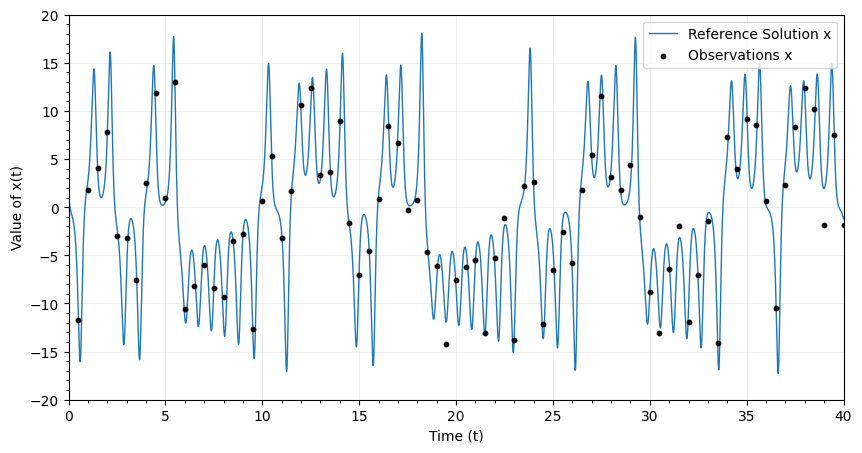

In [3]:
ref_sol, ref_ts = model.reference_solution
obs, obs_ts = model.observations

plt.figure(figsize=(10, 5))

plt.plot(ref_ts, ref_sol[:,0], linewidth=1, label='Reference Solution x')
plt.scatter(obs_ts, obs[:,0], s=10, c='Black', zorder=2, label='Observations x')

plt.xlabel('Time (t)')
plt.xlim(0, 40)
plt.ylabel('Value of x(t)')
plt.ylim(-20, 20)
plt.legend()
plt.minorticks_on()
plt.grid(alpha=0.2)

plt.show()

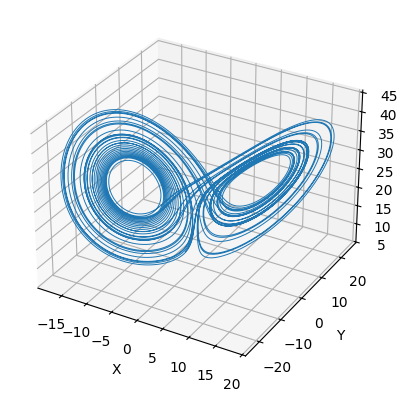

In [4]:

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot3D(ref_sol[:,0], ref_sol[:,1], ref_sol[:,2], linewidth=0.7)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

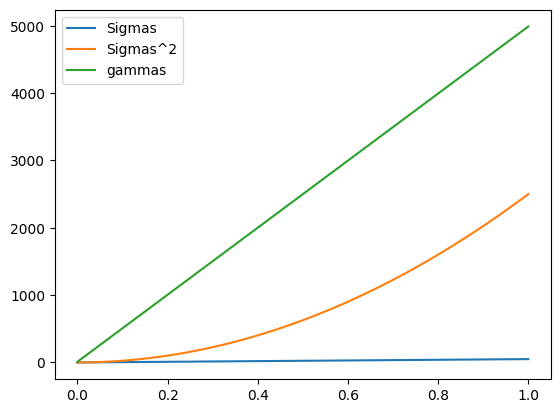

In [5]:
sigma_begin = 0.1 # Greater than the smallest dist
sigma_end = 50
N_tsteps = 150
sigmas = np.linspace(sigma_begin, sigma_end, N_tsteps)
taus = np.linspace(0, 1, N_tsteps)

dtau = taus[1] - taus[0]  # Time step (assuming uniform spacing)
dsigma_dtau = np.gradient(sigmas, dtau)

gammas = 2 * sigmas * dsigma_dtau

plt.figure()
plt.plot(taus, sigmas, label="Sigmas")
plt.plot(taus, sigmas**2, label="Sigmas^2")
plt.plot(taus, gammas, label="gammas")
plt.legend()
plt.show()

In [6]:

gauss_mix = GaussianMixture()
states, times = gauss_mix.filter(model, 40, 0.5, sigmas, gammas)

0, 0.0
Get Initialize states
1, 0.5
Predicting
Observation exists at this time
observation = [-11.74590588 -17.75776882  17.0919687 ]
2, 1.0
Predicting
Observation exists at this time
observation = [ 1.81908081  6.91836661 16.21098938]
3, 1.5
Predicting
Observation exists at this time
observation = [ 4.0626385  -0.12112676 27.48391661]
4, 2.0
Predicting
Observation exists at this time
observation = [ 7.77172919 12.33630857 14.22079195]
5, 2.5
Predicting
Observation exists at this time
observation = [-3.02751526 -1.53386162 18.96706862]
6, 3.0
Predicting
Observation exists at this time
observation = [-3.19854885 -1.24108174 32.24573486]
7, 3.5
Predicting
Observation exists at this time
observation = [ -7.55990008 -10.82087878  13.21376837]
8, 4.0
Predicting
Observation exists at this time
observation = [ 2.4948324  4.6509336 18.7083002]
9, 4.5
Predicting
Observation exists at this time
observation = [11.89323773  2.10897414 34.10641771]
10, 5.0
Predicting
Observation exists at this time

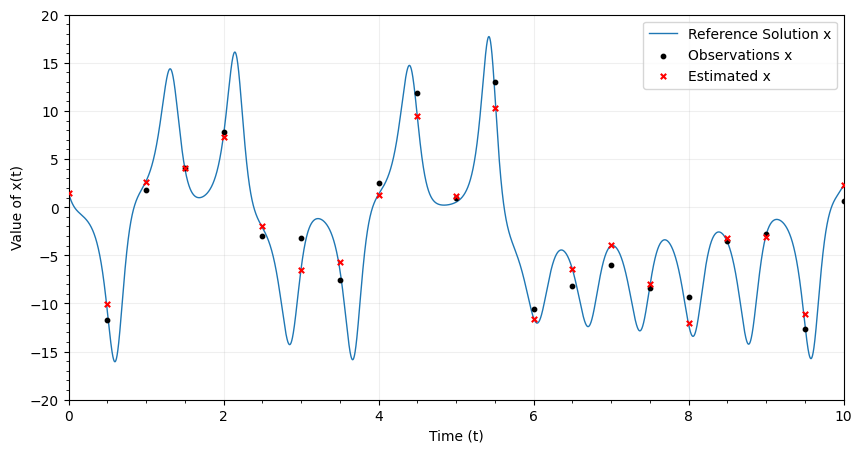

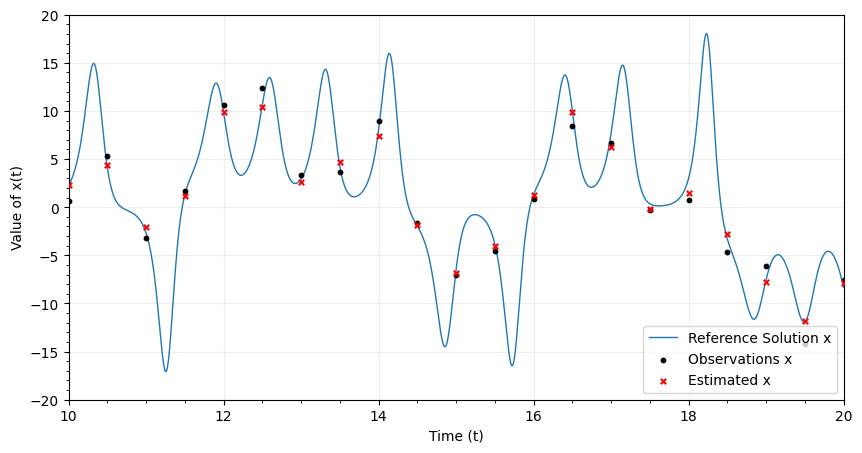

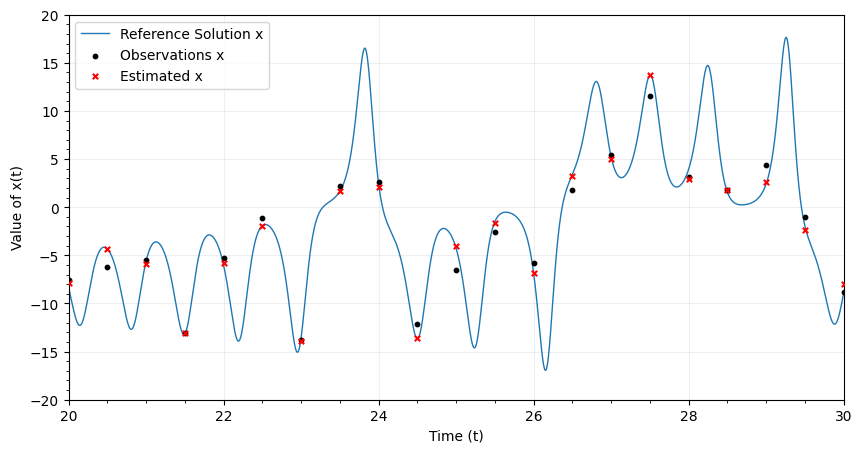

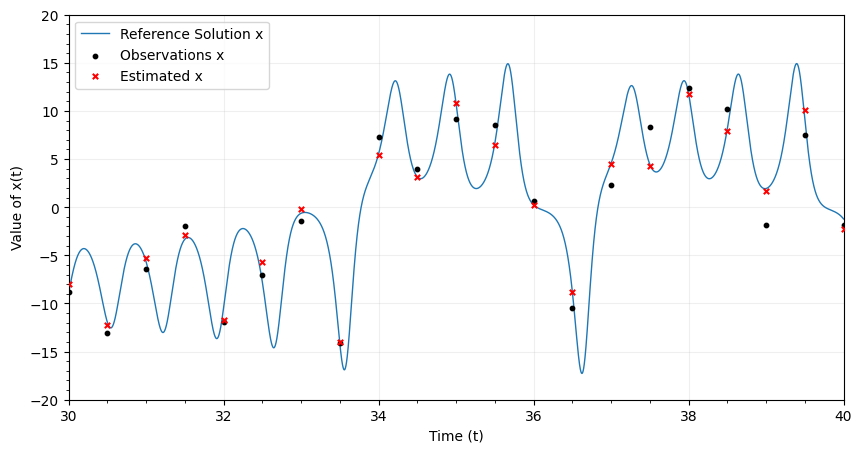

In [80]:
avg_states = np.mean(states, axis=1)
# errors = np.std(states, axis=1)
# print(errors.shape)

def timeplot(t_begin, t_end):
    plt.figure(figsize=(10, 5))

    plt.plot(ref_ts, ref_sol[:,0], linewidth=1, label='Reference Solution x')
    plt.scatter(obs_ts, obs[:,0], s=10, c='Black', zorder=2, label='Observations x')
    plt.scatter(times, avg_states[:,0], s=15, c='Red', zorder=3, marker='x', label='Estimated x')

    plt.xlabel('Time (t)')
    plt.xlim(t_begin, t_end)
    plt.ylabel('Value of x(t)')
    plt.ylim(-20, 20)
    plt.legend()
    plt.minorticks_on()
    plt.grid(alpha=0.2)

    plt.show()

timeplot(0,10)
timeplot(10,20)
timeplot(20,30)
timeplot(30,40)

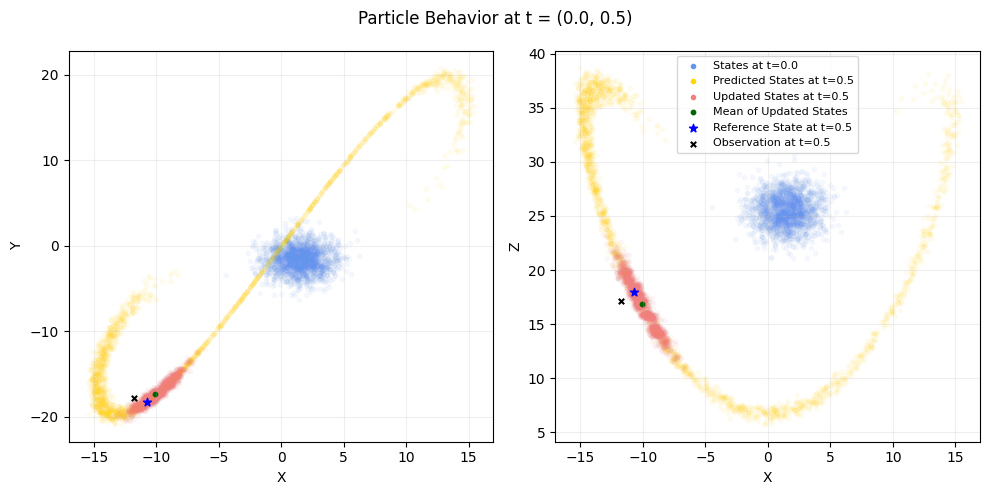

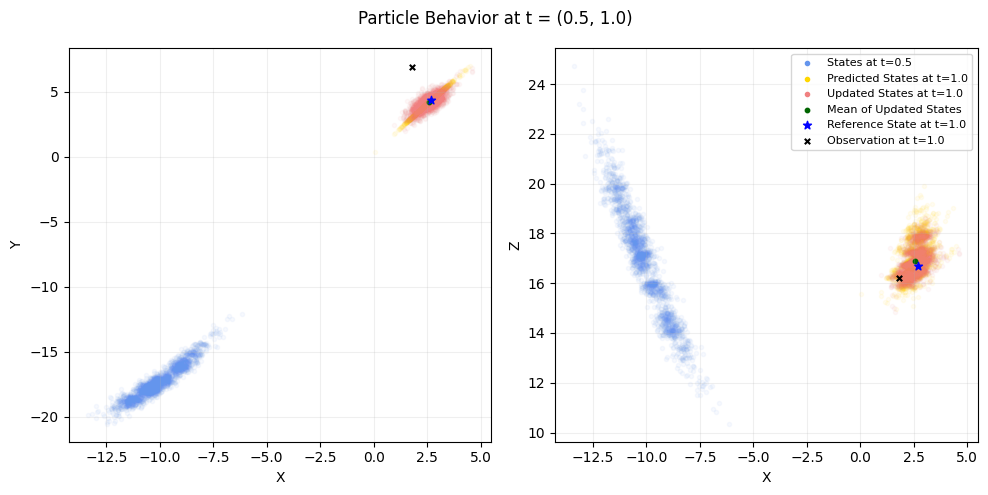

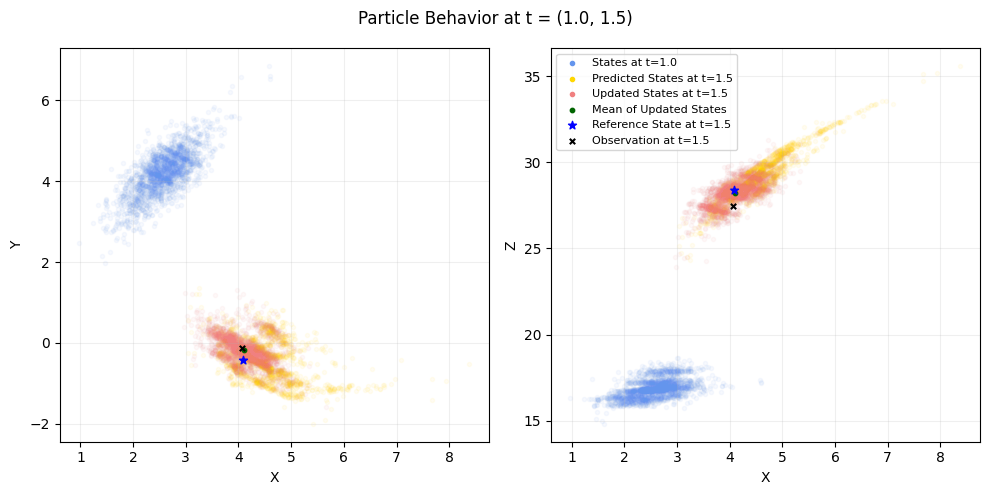

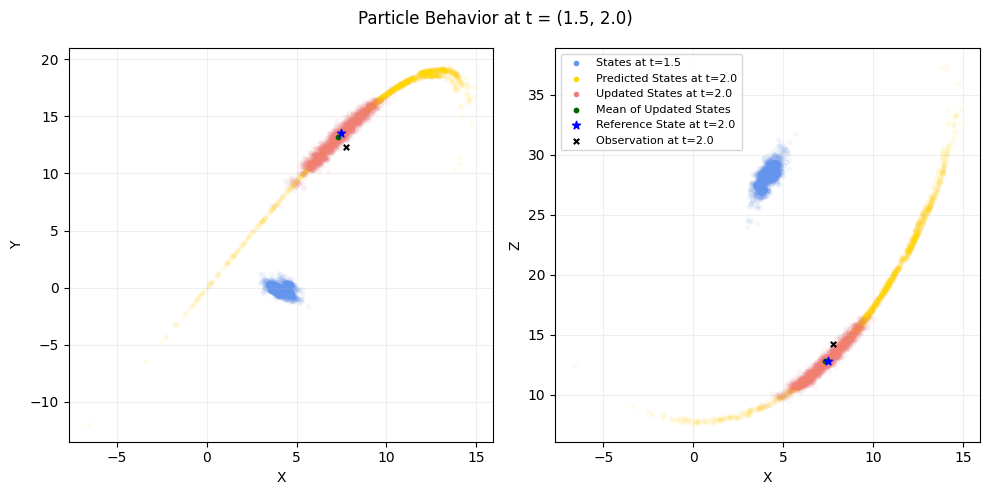

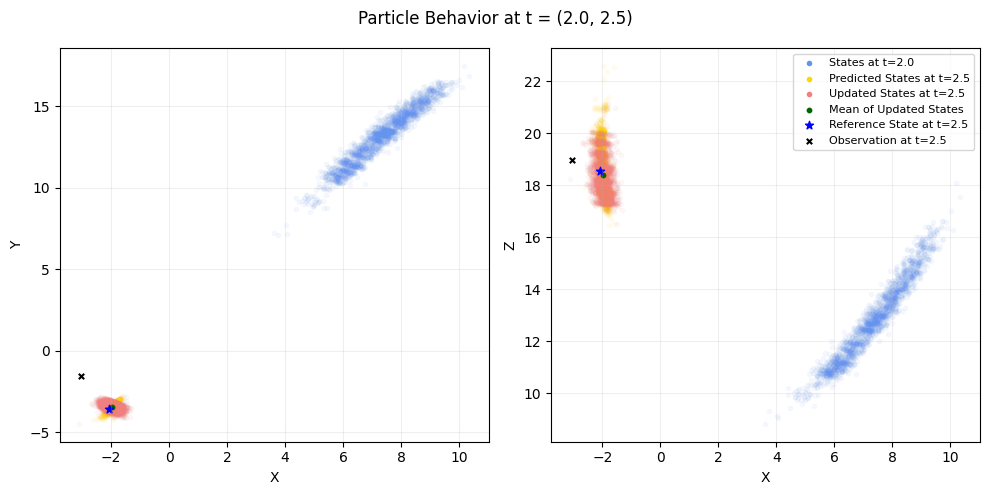

In [70]:
def plot_particles(idx1, idx2):

    sts_alpha = 0.05
    prior_clr = 'cornflowerblue'
    pred_clr = 'gold'
    upd_clr = 'lightcoral'
    mean_clr = 'darkgreen'
    ref_clr = 'blue'

    predicted_states = model.predict(states[idx2-1], times[idx2-1], times[idx2])

    # ref_t_idx1 = np.where(times[idx1] == ref_ts)[0][0]
    ref_t_idx2 = np.where(times[idx2] == ref_ts)[0][0]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    fig.suptitle(f"Particle Behavior at t = ({times[idx1]}, {times[idx2]})")

    ax1.scatter(states[idx1][:,0], states[idx1][:,1], alpha=sts_alpha, marker='.', color=prior_clr, label=f"States at t={times[idx1]}")
    ax1.scatter(predicted_states[:,0], predicted_states[:,1], alpha=sts_alpha, marker='.', color=pred_clr, label=f"Predicted States at t={times[idx2]}")
    ax1.scatter(states[idx2][:,0], states[idx2][:,1], alpha=sts_alpha, marker='.', color=upd_clr, label=f"Updated States at t={times[idx2]}")
    ax1.scatter(avg_states[idx2][0], avg_states[idx2][1], s=10, color=mean_clr, label=f"Mean of Updated States")
    ax1.scatter(ref_sol[ref_t_idx2][0], ref_sol[ref_t_idx2][1], marker='*', color=ref_clr, label=f"Reference State at t={times[idx2]}")
    ax1.scatter(obs[idx2 - 1][0], obs[idx2 - 1][1], s=15, marker='x', color="Black", label=f"Observation at t={times[idx2]}")
    

    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.grid(alpha=0.2)
    # ax1.legend()

    ax2.scatter(states[idx1][:,0], states[idx1][:,2], alpha=sts_alpha, marker='.', color=prior_clr, label=f"States at t={times[idx1]}")
    ax2.scatter(predicted_states[:,0], predicted_states[:,2], alpha=sts_alpha, marker='.', color=pred_clr, label=f"Predicted States at t={times[idx2]}")
    ax2.scatter(states[idx2][:,0], states[idx2][:,2], alpha=sts_alpha, marker='.', color=upd_clr, label=f"Updated States at t={times[idx2]}")
    ax2.scatter(avg_states[idx2][0], avg_states[idx2][2], s=10, color=mean_clr, label=f"Mean of Updated States")
    ax2.scatter(ref_sol[ref_t_idx2][0], ref_sol[ref_t_idx2][2], marker='*', color=ref_clr, label=f"Reference State at t={times[idx2]}")
    ax2.scatter(obs[idx2 - 1][0], obs[idx2 - 1][2], s=15, marker='x', color="Black", label=f"Observation at t={times[idx2]}")

    ax2.set_xlabel("X")
    ax2.set_ylabel("Z")
    ax2.grid(alpha=0.2)
    # ax2.legend()

    legend = plt.legend(fontsize="8")

    for lh in legend.legend_handles: 
        lh.set_alpha(1)

    plt.tight_layout()
    plt.show()

plot_particles(0, 1)
plot_particles(1, 2)
plot_particles(2, 3)
plot_particles(3, 4)
plot_particles(4, 5)